# 9.5. Recurrent Neural Network Implementation from Scratch

## 📘 Code Along

In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F

import sys
sys.path.append("../..")
from models import RNNScratch
from models import RNNLMScratch
from dataloaders import TimeMachine
from utils import Trainer

### 9.5.1. RNN Model

In [2]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

In [3]:
def check_len(a, n):
    """Check the length of a list."""
    assert len(a) == n, f'list\'s length {len(a)} != expected length {n}'

def check_shape(a, shape):
    """Check the shape of a tensor."""
    assert a.shape == shape, \
            f'tensor\'s shape {a.shape} != expected shape {shape}'

check_len(outputs, num_steps)
check_shape(outputs[0], (batch_size, num_hiddens))
check_shape(state, (batch_size, num_hiddens))

### 9.5.2. RNN-Based Language Model

In [4]:
F.one_hot(torch.tensor([0, 2]), 5)

tensor([[1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0]])

In [5]:
model = RNNLMScratch(rnn, num_inputs)
outputs = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
check_shape(outputs, (batch_size, num_steps, num_inputs))

### 9.5.3. Gradient Clipping

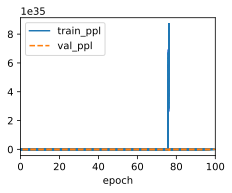

In [8]:
data = TimeMachine(batch_size=1024, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLMScratch(rnn, vocab_size=len(data.vocab), lr=1)
trainer = Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 9.5.5. Decoding

In [9]:
model.predict('it has', 20, data.vocab, torch.device(f'mps:{1}'))

'it hasgggggggggggggggggggg'